In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
## read the dataset
df=pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


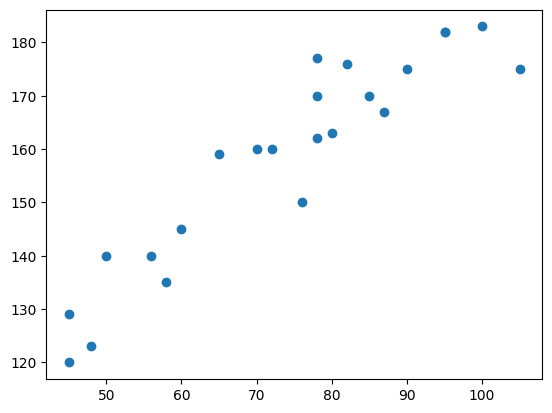

In [7]:
plt.scatter(df['Weight'],df['Height'])

In [8]:
x=df.iloc[:,:-1].values
y=df.iloc[:,-1].values

In [9]:
x

array([[ 45],
       [ 58],
       [ 48],
       [ 60],
       [ 70],
       [ 78],
       [ 80],
       [ 90],
       [ 95],
       [ 78],
       [ 82],
       [ 95],
       [105],
       [100],
       [ 85],
       [ 78],
       [ 50],
       [ 65],
       [ 76],
       [ 87],
       [ 45],
       [ 56],
       [ 72]])

In [10]:
y

array([120, 135, 123, 145, 160, 162, 163, 175, 182, 170, 176, 182, 175,
       183, 170, 177, 140, 159, 150, 167, 129, 140, 160])

In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [20]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((17, 1), (6, 1), (17,), (6,))

In [22]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [ ]:
sc.fit_transform(x_train)

array([[-0.87662801],
       [ 1.66773133],
       [ 0.33497168],
       [-1.48242785],
       [ 1.36483141],
       [-1.6641678 ],
       [-0.75546804],
       [-0.1496682 ],
       [ 0.21381171],
       [-1.36126788],
       [-0.99778797],
       [-0.02850823],
       [ 1.06193149],
       [ 0.57729161],
       [ 0.75903157],
       [ 0.88019153],
       [ 0.45613165]])

In [25]:
sc.transform(x_test)

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

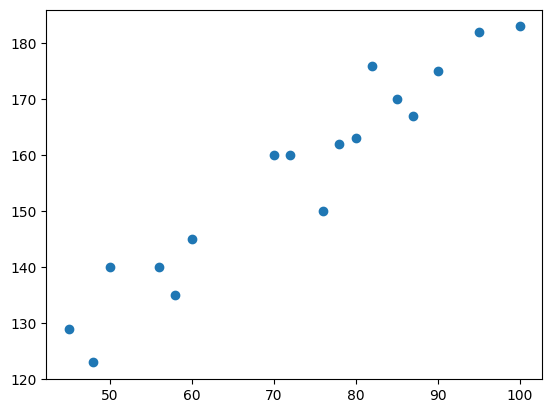

In [26]:
plt.scatter(x_train,y_train)

In [30]:
## train the model
from sklearn.linear_model import LinearRegression
regresser=LinearRegression()
regresser.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
print("The slope :",regresser.coef_)

The slope : [1.04792503]


In [35]:
print("intercept:",regresser.intercept_)

intercept: 80.52684512622542


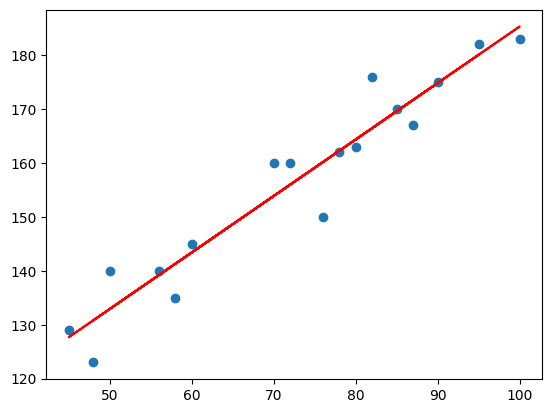

In [45]:
plt.scatter(x_train,y_train)
plt.plot(x_train,regresser.predict(x_train),'r')

In [48]:
y_pred_test=regresser.predict(x_test)
y_pred_test,y_test

(array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
        148.64197186, 190.55897293]),
 array([177, 170, 120, 182, 159, 175]))

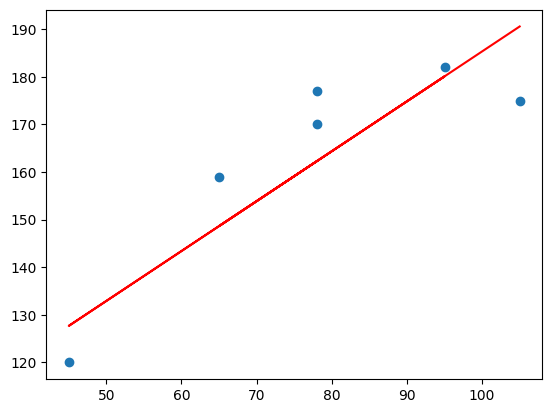

In [50]:
plt.scatter(x_test,y_test)
plt.plot(x_test,regresser.predict(x_test),'r')

In [55]:
## performance metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error
mae=mean_absolute_error(y_test,y_pred_test)
mse=mean_squared_error(y_test,y_pred_test)
rmse=np.sqrt(mse)

In [56]:
mae,mse,rmse

(9.665125886795005, 114.84069295228686, np.float64(10.7163749912126))

In [57]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred_test)

In [59]:
r2

0.7360826717981279

In [61]:
## adjusted r2
1-(1-r2)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)


0.6701033397476599

In [63]:
regresser

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [65]:
## new data point weight is 80
weight_scaled=sc.transform([[80]])

In [66]:
weight_scaled

array([[0.45613165]])

In [67]:
pred_weight=regresser.predict(weight_scaled)

In [68]:
pred_weight

array([81.00483689])

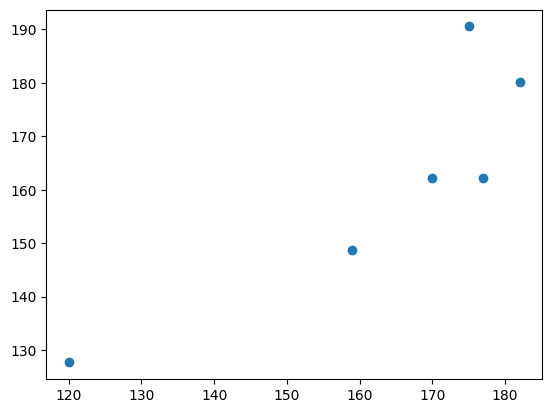

In [ ]:
## when do you say that model is good
# plot a scatter plot for the prediction
plt.scatter(y_test,y_pred_test)## if linearly plotted then good

In [71]:
## residuals
residuals=y_test-y_pred_test

In [72]:
residuals

array([ 14.73500279,   7.73500279,  -7.68347133,   1.92027734,
        10.35802814, -15.55897293])

C:\Users\preet\AppData\Local\Temp\ipykernel_24728\1261763181.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals,kde=True)


<Axes: ylabel='Density'>

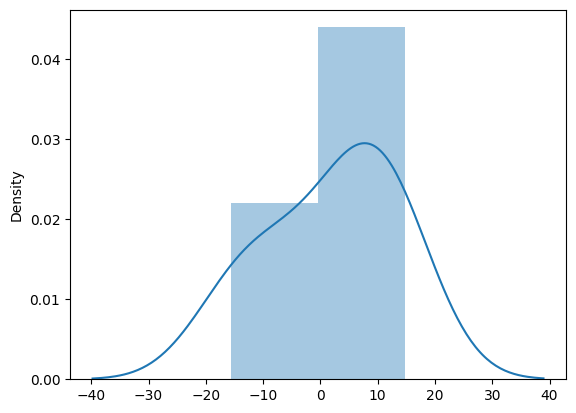

In [76]:
## plot residuals
import seaborn as sns
sns.distplot(residuals,kde=True)

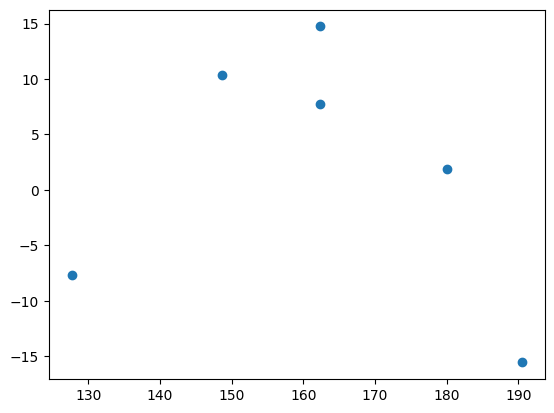

In [ ]:
## data must be uniformly distributed
plt.scatter(y_pred_test,residuals)